# Importing Libaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.tree import plot_tree
from xgboost import plot_importance,XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("/kaggle/input/covertype-forest-cover-types/covertype.csv")
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


# Data Exploration

In [3]:
df.shape

(581012, 55)

In [4]:
df = df.rename(columns = {'Unnamed: 0': 'Feature_0' , 'Unnamed: 1': 'Feature_1' , 'Unnamed: 2': 'Feature_2'})
df.head()

,Feature_0,Feature_1,Feature_2,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [5]:
df.isnull().sum()

Feature_0                             0
Feature_1                             0
Feature_2                             0
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area                       0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0


In [6]:
df.describe()

,Feature_0,Feature_1,Feature_2,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


**prepare features and target variable for classification**

# Train and Test

In [7]:
X = df.drop(columns=["Cover_Type"])
y = df["Cover_Type"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
rf = RandomForestClassifier(n_estimators = 300 , random_state = 42, max_depth=None , class_weight = 'balanced')
rf.fit(X_train , y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

# Evaluation of Random Forest

In [10]:
y_pred = rf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"\nRandom Forest Accuracy: {acc*100:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Random Forest Accuracy: 95.5199

Classification Report:
              precision    recall  f1-score   support

           1     0.9669    0.9427    0.9546     42368
           2     0.9496    0.9747    0.9619     56661
           3     0.9375    0.9614    0.9493      7151
           4     0.9062    0.8452    0.8746       549
           5     0.9482    0.7909    0.8625      1899
           6     0.9353    0.8912    0.9127      3473
           7     0.9745    0.9495    0.9618      4102

    accuracy                         0.9552    116203
   macro avg     0.9455    0.9079    0.9254    116203
weighted avg     0.9554    0.9552    0.9550    116203



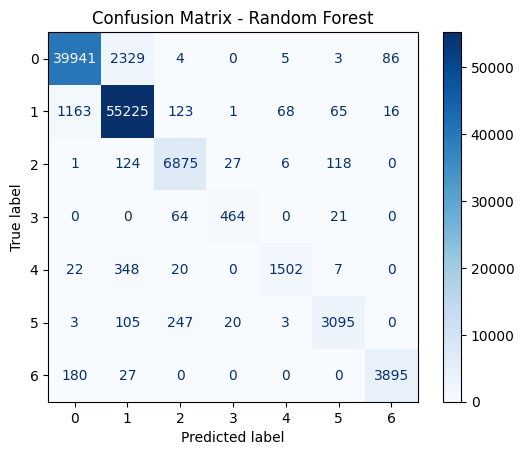

In [11]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Evaluation of XGBoost

In [12]:
y_train = y_train - 1
y_test = y_test - 1

**Starting from 0 for XGBoost compatibility**

In [13]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3],
    'min_child_weight': [1, 3, 5]
}
xgb = XGBClassifier(random_state=42, objective="multi:softmax",num_class=7
, use_label_encoder=False, eval_metric='mlogloss')
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=20,     
    scoring='accuracy',
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
print("Best Params:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Params: {'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 3, 'max_depth': 10, 'learning_rate': 0.1, 'gamma': 0.2, 'colsample_bytree': 0.8}
Best Score: 0.9547513075656813


**Finding best prameters for better Evaluation**

In [14]:
best_model = XGBClassifier(
    random_state=42,
    objective="multi:softmax",
    num_class=7,
    use_label_encoder=False,
    eval_metric='mlogloss',
    subsample=0.8,
    n_estimators=400,
    min_child_weight=3,
    max_depth=10,
    learning_rate=0.1,
    gamma=0.2,
    colsample_bytree=0.8
)

best_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=0.2, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
              max_leaves=None, min_child_weight=3, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=400,
              n_jobs=None, num_class=7, num_parallel_tree=None, ...)

In [15]:
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nXGBoost Accuracy: {acc*100:.4f}")
print(classification_report(y_test , y_pred))


XGBoost Accuracy: 95.9390
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     42368
           1       0.96      0.97      0.96     56661
           2       0.96      0.96      0.96      7151
           3       0.91      0.88      0.89       549
           4       0.94      0.87      0.91      1899
           5       0.94      0.93      0.93      3473
           6       0.97      0.97      0.97      4102

    accuracy                           0.96    116203
   macro avg       0.95      0.93      0.94    116203
weighted avg       0.96      0.96      0.96    116203



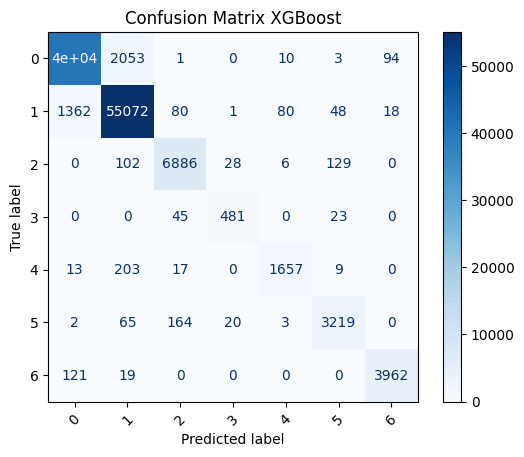

In [16]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix XGBoost")
plt.show()

In [17]:
rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
xgb_importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Visualization for Top Features

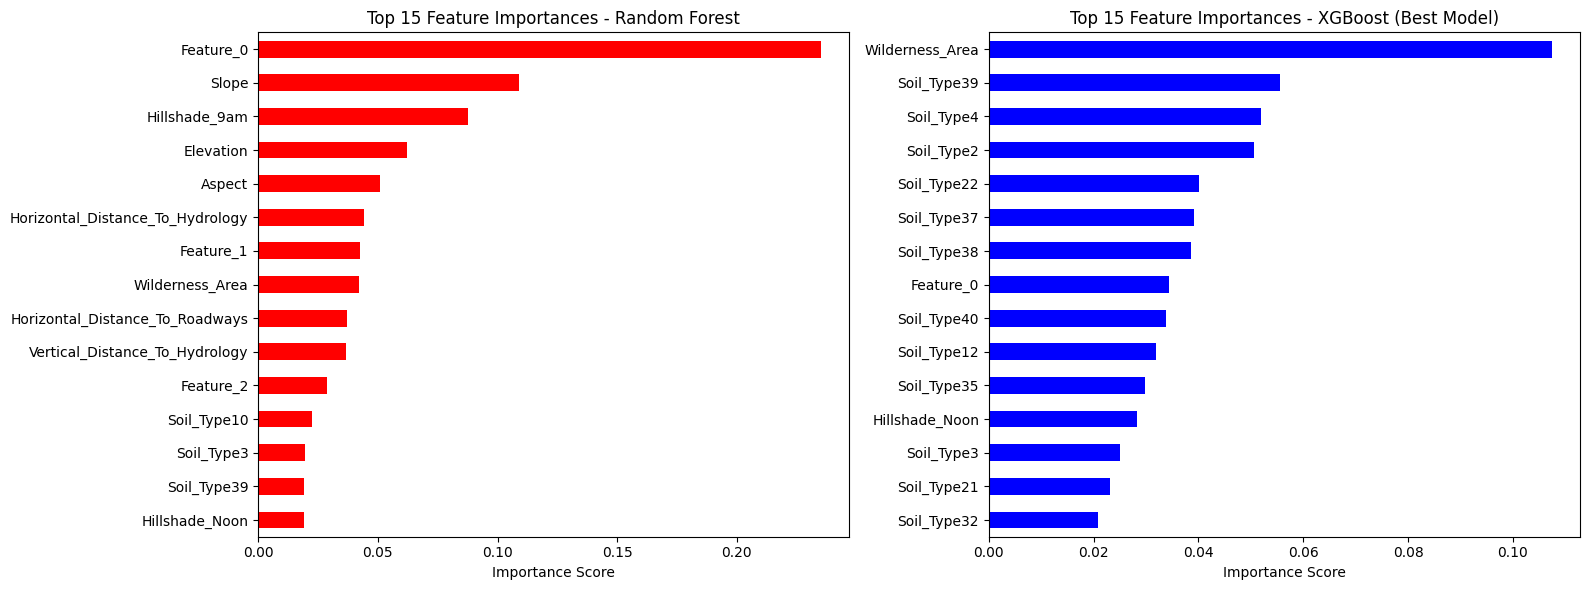

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

rf_importances.head(15).sort_values().plot(
    kind='barh', color='red', ax=axes[0]
)
axes[0].set_title("Top 15 Feature Importances - Random Forest")
axes[0].set_xlabel("Importance Score")

xgb_importances.head(15).sort_values().plot(
    kind='barh', color='blue', ax=axes[1]
)
axes[1].set_title("Top 15 Feature Importances - XGBoost (Best Model)")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.show()